# Use of Songs Added in the 1991 Edition

This notebook explores how songs newly added to the 1991 Denson edition were used over time, including overall yearly contours, song-by-song trajectories, and regional differences.

Metric notes:

- A **lesson** is counted as one distinct `(minutes_id, lesson_id, song_id)`, so two people jointly leading the same song in the same lesson do not double count the song.
- A **singing record/day** is counted as one `minutes` row. Some rows cover multi-day conventions, so treat this as a practical database unit rather than a perfect day-level measure.
- `minutes.Year` is the minute-book year, not always the singing year. The notebook derives `singing_year` from `DateOrdinal` when available and otherwise parses `minutes.Date`.

In [69]:
# @title
from pathlib import Path
import datetime as dt
import itertools
import re
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns
sns.set_theme(style="whitegrid")

DB_PATH = Path("minutes_pre95.db")
NEW_SONGS_PATH = Path("1991newsongs.txt")
REMOVED_SONGS_PATH = Path("1991removedsongs.txt")

assert DB_PATH.exists(), f"Missing database: {DB_PATH}"
assert NEW_SONGS_PATH.exists(), f"Missing new-song list: {NEW_SONGS_PATH}"
assert REMOVED_SONGS_PATH.exists(), f"Missing removed-song list: {REMOVED_SONGS_PATH}"

## Load Song And Minutes Data

In [70]:
# @title
def read_1991_new_songs(path: Path) -> pd.DataFrame:
    rows = []
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        page, title = line.split(" ", 1)
        rows.append({"page_num": page, "listed_title": title})
    return pd.DataFrame(rows)

conn = sqlite3.connect(DB_PATH)

new_song_pages = read_1991_new_songs(NEW_SONGS_PATH)

songs_1991 = pd.read_sql_query(
    """
    SELECT bsj.page_num, bsj.song_id, songs.title
    FROM book_song_joins bsj
    JOIN books ON books.id = bsj.book_id
    JOIN songs ON songs.id = bsj.song_id
    WHERE books.year = 1991
    """,
    conn,
)

new_songs = new_song_pages.merge(songs_1991, on="page_num", how="left")
missing = new_songs[new_songs.song_id.isna()]
assert missing.empty, missing
new_songs["song_id"] = new_songs["song_id"].astype(int)
new_song_ids = set(new_songs.song_id)

minutes = pd.read_sql_query(
    """
    SELECT id AS minutes_id, Name, Location, Date, Year AS book_year,
           DateOrdinal, DensonYear, IsDenson, IsVirtual
    FROM minutes
    WHERE IsDenson = 1 AND COALESCE(IsVirtual, 0) = 0
    """,
    conn,
)

lessons = pd.read_sql_query(
    """
    SELECT DISTINCT minutes_id, lesson_id, song_id
    FROM song_leader_joins
    WHERE minutes_id IS NOT NULL AND lesson_id IS NOT NULL AND song_id IS NOT NULL
    """,
    conn,
)

leaders_by_minutes = pd.read_sql_query(
    """
    SELECT DISTINCT minutes_id, leader_id
    FROM song_leader_joins
    WHERE minutes_id IS NOT NULL AND leader_id IS NOT NULL
    """,
    conn,
)

location_rows = pd.read_sql_query(
    """
    SELECT mlj.minutes_id,
           GROUP_CONCAT(DISTINCT locations.state_province) AS state_province,
           GROUP_CONCAT(DISTINCT locations.country) AS country
    FROM minutes_location_joins mlj
    JOIN locations ON locations.id = mlj.location_id
    GROUP BY mlj.minutes_id
    """,
    conn,
)

conn.close()

new_songs.head(), minutes.shape, lessons.shape

(  page_num listed_title  song_id       title
 0      34b   St. Thomas       17  St. Thomas
 1      50b     Humility       45    Humility
 2      50t    Mortality       43   Mortality
 3       66       Jordan       67      Jordan
 4      77b     Holcombe       86    Holcombe,
 (6789, 9),
 (548686, 3))

## Derive Singing Year


In [71]:
# @title
MONTHS = "January February March April May June July August September October November December".split()
DATE_RE = re.compile(r"(" + "|".join(MONTHS) + r")\s+(\d{1,2}).*?(\d{4})", re.I)
MONTH_RE = re.compile(r"(" + "|".join(MONTHS) + r")", re.I)
CURRENT_YEAR = dt.date.today().year


def plausible_singing_year(year, book_year=None):
    if pd.isna(year):
        return False
    year = int(year)
    if year < 1980 or year > CURRENT_YEAR + 1:
        return False
    if pd.notna(book_year) and abs(year - int(book_year)) > 1:
        return False
    return True


def fallback_year_from_book(row):
    if pd.isna(row.book_year):
        return np.nan
    book_year = int(row.book_year)
    month_match = MONTH_RE.search(str(row.Date))
    if month_match and month_match.group(1).lower() == "december":
        return book_year - 1
    return book_year


def singing_year_from_row(row) -> float:
    ordinal_year = np.nan
    if pd.notna(row.DateOrdinal):
        try:
            ordinal_year = dt.date.fromordinal(int(row.DateOrdinal)).year
        except ValueError:
            ordinal_year = np.nan
    if plausible_singing_year(ordinal_year, row.book_year):
        return int(ordinal_year)

    match = DATE_RE.search(str(row.Date))
    text_year = int(match.group(3)) if match else np.nan
    if plausible_singing_year(text_year, row.book_year):
        return int(text_year)

    return fallback_year_from_book(row)

STATE_ALIASES = {
    "alabama": "AL", "al": "AL", "georgia": "GA", "ga": "GA",
    "mississippi": "MS", "ms": "MS", "tennessee": "TN", "tn": "TN",
    "florida": "FL", "fl": "FL", "texas": "TX", "tx": "TX",
    "louisiana": "LA", "la": "LA", "arkansas": "AR", "ar": "AR",
    "north carolina": "NC", "nc": "NC", "south carolina": "SC", "sc": "SC",
    "virginia": "VA", "va": "VA", "west virginia": "WV", "wv": "WV",
    "kentucky": "KY", "ky": "KY", "illinois": "IL", "il": "IL",
    "indiana": "IN", "in": "IN", "ohio": "OH", "oh": "OH",
    "michigan": "MI", "mi": "MI", "wisconsin": "WI", "wi": "WI",
    "minnesota": "MN", "mn": "MN", "missouri": "MO", "mo": "MO",
    "iowa": "IA", "ia": "IA", "kansas": "KS", "ks": "KS",
    "california": "CA", "ca": "CA", "oregon": "OR", "or": "OR",
    "washington": "WA", "wa": "WA", "colorado": "CO", "co": "CO",
    "new mexico": "NM", "nm": "NM", "arizona": "AZ", "az": "AZ",
    "new york": "NY", "ny": "NY", "massachusetts": "MA", "ma": "MA",
    "connecticut": "CT", "ct": "CT", "vermont": "VT", "vt": "VT",
    "maine": "ME", "me": "ME", "pennsylvania": "PA", "pa": "PA",
    "maryland": "MD", "md": "MD", "oregon": "OR", "ireland": "IE",
    "united kingdom": "UK", "england": "UK", "ontario": "ON", "canada": "CA-Canada",
}

def normalize_state(value):
    if pd.isna(value) or not str(value).strip():
        return None
    first = str(value).split(",")[0].strip()
    key = first.lower().replace(".", "")
    return STATE_ALIASES.get(key, first.upper() if len(first) == 2 else first)

def infer_state_from_text(*parts):
    text = " ".join(str(p) for p in parts if pd.notna(p)).lower().replace(".", " ")
    # Prefer long names before abbreviations so "Georgia" beats a stray "GA"-like token.
    for key in sorted(STATE_ALIASES, key=len, reverse=True):
        if re.search(r"\b" + re.escape(key) + r"\b", text):
            return STATE_ALIASES[key]
    return None

minutes = minutes.merge(location_rows, on="minutes_id", how="left")
minutes["singing_year"] = minutes.apply(singing_year_from_row, axis=1)
minutes["state"] = minutes["state_province"].map(normalize_state)
missing_state = minutes["state"].isna()
minutes.loc[missing_state, "state"] = minutes.loc[missing_state].apply(
    lambda row: infer_state_from_text(row.Location, row.Name), axis=1
)

year_audit = minutes.loc[
    (minutes.singing_year < 1980) |
    (minutes.singing_year > CURRENT_YEAR + 1) |
    (minutes.book_year.notna() & ((minutes.singing_year - minutes.book_year).abs() > 1)),
    ["minutes_id", "Name", "Date", "book_year", "DateOrdinal", "singing_year"],
]
assert year_audit.empty, year_audit

minutes[["minutes_id", "Name", "Date", "book_year", "singing_year", "state"]].head(10)

,minutes_id,Name,Date,book_year,singing_year,state
0,1,Liberty Church,"December 4, 1994",1995,1994,AL
1,2,Concord Primitive Baptist Church,"December 11, 1994",1995,1994,AL
2,3,Little Branch Primitive Baptist Church,"December 15, 1994",1995,1994,AL
3,4,Dutch Treat Singing,"January 1, 1995",1995,1995,AL
4,5,Original Dutch Singing,"January 1, 1995",1995,1995,GA
5,6,Friends Meetinghouse,"January 2, 1995",1995,1995,OH
6,8,Lillian Calvert and Irene Woodley Memorial,"January 7, 1995",1995,1995,AL
7,9,Jack and Henry Kerr Memorial,"January 8, 1995",1995,1995,AL
8,10,Anniversary Singing,"January 8, 1995",1995,1995,IL
9,11,All-California Sacred Harp Singing Convention,"January 15, 1995",1995,1995,CA


## Overall Yearly Use Of 1991 New Songs

In [72]:
# @title
lesson_facts = lessons.merge(
    minutes[["minutes_id", "singing_year"]],
    on="minutes_id",
    how="inner",
)
lesson_facts = lesson_facts.dropna(subset=["singing_year"])
lesson_facts["singing_year"] = lesson_facts["singing_year"].astype(int)
lesson_facts["is_1991_new"] = lesson_facts.song_id.isin(new_song_ids)

year_total = lesson_facts.groupby("singing_year").agg(
    total_lessons=("song_id", "size"),
    singing_records=("minutes_id", "nunique"),
)
year_new = lesson_facts[lesson_facts.is_1991_new].groupby("singing_year").agg(
    new_song_lessons=("song_id", "size"),
    records_with_new_song=("minutes_id", "nunique"),
)

yearly = year_total.join(year_new, how="left").fillna(0)
yearly["share_of_lessons"] = yearly.new_song_lessons / yearly.total_lessons
yearly["share_of_records"] = yearly.records_with_new_song / yearly.singing_records
yearly = yearly.reset_index()
yearly.head()

,singing_year,total_lessons,singing_records,new_song_lessons,records_with_new_song,share_of_lessons,share_of_records
0,1992,13847,151,1543,136,0.111432,0.900662
1,1993,14211,162,1411,150,0.099289,0.925926
2,1994,14344,162,1324,154,0.092303,0.950617
3,1995,13647,164,1277,159,0.093574,0.969512
4,1996,13858,165,1351,157,0.097489,0.951515


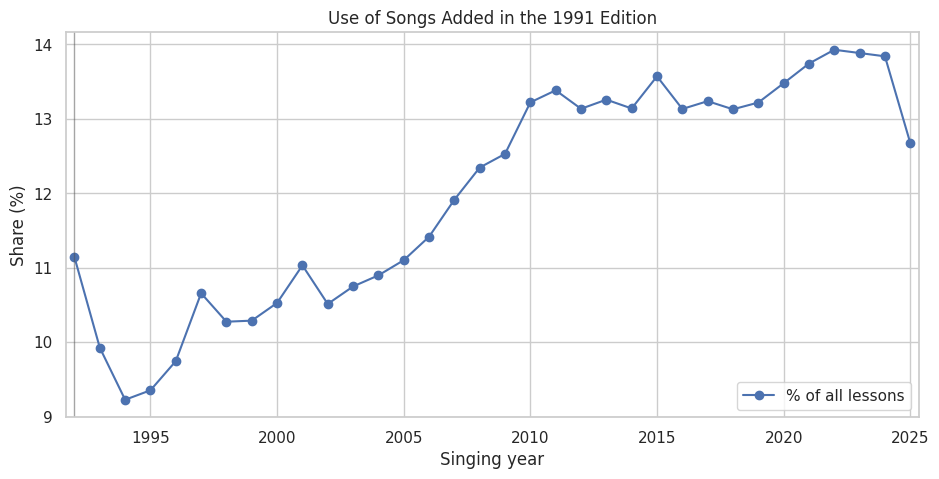

In [73]:
# @title
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly.singing_year, yearly.share_of_lessons * 100, marker="o", label="% of all lessons")
# ax.plot(yearly.singing_year, yearly.share_of_records * 100, marker="o", label="% of singing records with any 1991 new song")
ax.axvline(1992, color="0.3", lw=1, alpha=0.5)
ax.set_title("Use of Songs Added in the 1991 Edition")
ax.set_xlabel("Singing year")
ax.set_ylabel("Share (%)")
ax.legend()
ax.margins(x=0.01)
plt.show()

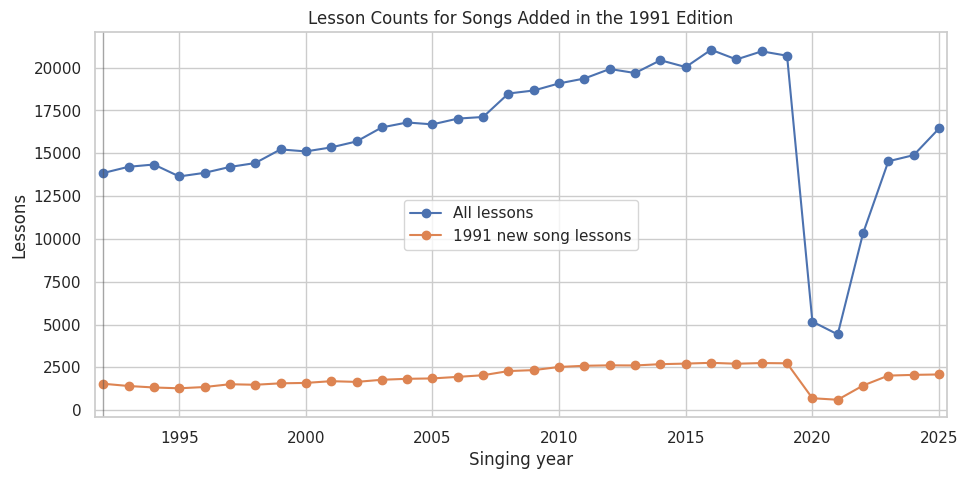

In [74]:
# @title
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly.singing_year, yearly.total_lessons, marker="o", label="All lessons")
ax.plot(yearly.singing_year, yearly.new_song_lessons, marker="o", label="1991 new song lessons")
ax.axvline(1992, color="0.3", lw=1, alpha=0.5)
ax.set_title("Lesson Counts for Songs Added in the 1991 Edition")
ax.set_xlabel("Singing year")
ax.set_ylabel("Lessons")
ax.legend()
ax.margins(x=0.01)
plt.show()

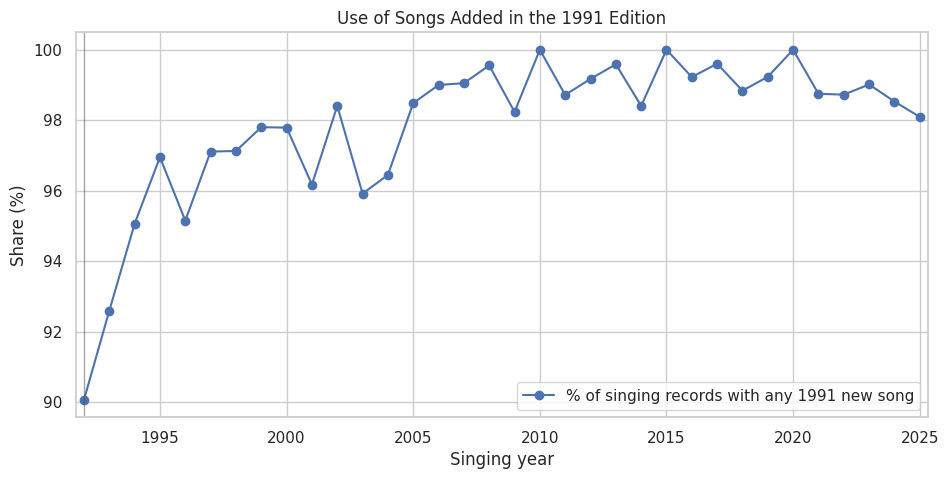

In [75]:
# @title
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly.singing_year, yearly.share_of_records * 100, marker="o", label="% of singing records with any 1991 new song")
ax.axvline(1992, color="0.3", lw=1, alpha=0.5)
ax.set_title("Use of Songs Added in the 1991 Edition")
ax.set_xlabel("Singing year")
ax.set_ylabel("Share (%)")
ax.legend()
ax.margins(x=0.01)
plt.show()

### Initial Burst vs Later Use

This bins the contour into eras. Change the year ranges if another periodization makes more sense.

In [76]:
# @title
bins = [1990, 1994, 1999, 2009, 2019, 2100]
labels = ["1992-1994", "1995-1999", "2000-2009", "2010-2019", "2020+"]
lesson_facts["era"] = pd.cut(lesson_facts.singing_year, bins=bins, labels=labels)
era_summary = lesson_facts.groupby("era", observed=True).agg(
    total_lessons=("song_id", "size"),
    new_song_lessons=("is_1991_new", "sum"),
    singing_records=("minutes_id", "nunique"),
)
era_days = lesson_facts[lesson_facts.is_1991_new].groupby("era", observed=True).minutes_id.nunique()
era_summary["records_with_new_song"] = era_days
era_summary = era_summary.fillna(0)
era_summary["share_of_lessons"] = era_summary.new_song_lessons / era_summary.total_lessons
era_summary["share_of_records"] = era_summary.records_with_new_song / era_summary.singing_records
era_summary

,total_lessons,new_song_lessons,singing_records,records_with_new_song,share_of_lessons,share_of_records
era,,,,,,
1992-1994,42402,4278,475,440,0.100891,0.926316
1995-1999,71361,7192,858,831,0.100783,0.968531
2000-2009,167439,18999,2005,1964,0.113468,0.979551
2010-2019,201693,26708,2477,2459,0.132419,0.992733
2020+,65791,8907,924,912,0.135383,0.987013


## Song-By-Song Trajectories of 1991 New Songs

In [77]:
# @title
song_year_counts = lesson_facts[lesson_facts.song_id.isin(new_song_ids)].groupby(["song_id", "singing_year"]).agg(
    lessons=("song_id", "size"),
    singing_records=("minutes_id", "nunique"),
).reset_index()
song_year_counts = song_year_counts.merge(year_total.reset_index(), on="singing_year", how="left")
song_year_counts = song_year_counts.merge(new_songs[["song_id", "page_num", "title"]], on="song_id", how="left")
song_year_counts["share_of_all_lessons"] = song_year_counts.lessons / song_year_counts.total_lessons
song_year_counts["share_of_records"] = song_year_counts.singing_records_x / song_year_counts.singing_records_y
song_year_counts = song_year_counts.rename(columns={"singing_records_x": "song_records", "singing_records_y": "all_records"})

top_new_songs = (song_year_counts.groupby(["song_id", "page_num", "title"]).lessons.sum()
                 .sort_values(ascending=False).head(40).reset_index())
top_new_songs

,song_id,page_num,title,lessons
0,549,475,A Thankful Heart,3722
1,214,178,Africa,3503
2,591,503,Lloyd,3318
3,17,34b,St. Thomas,2997
4,197,163b,China,2260
5,387,344,Rainbow,2255
6,264,225t,Reynolds,2215
7,546,472,Akin,2187
8,67,66,Jordan,2079
9,102,86,Poland,1959


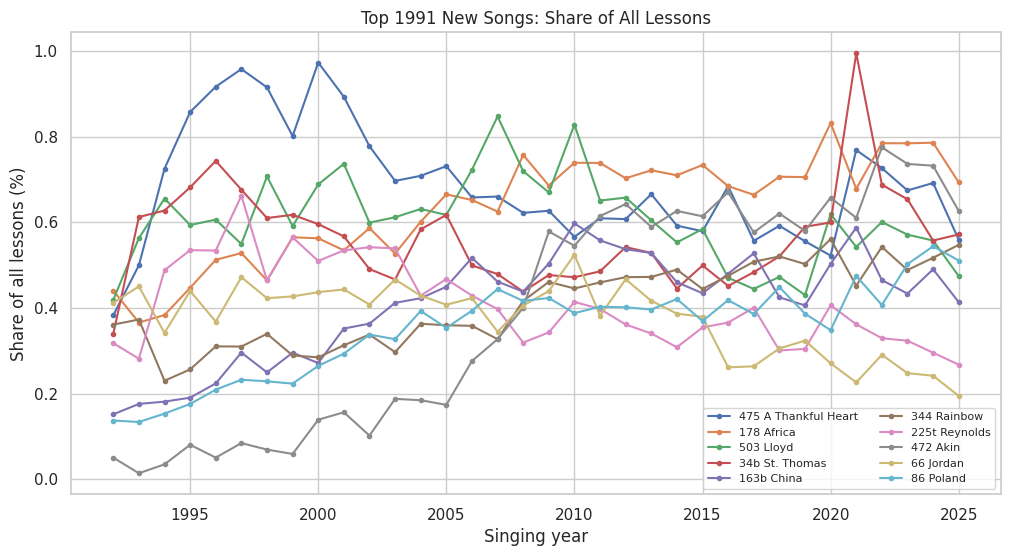

In [78]:
# @title
fig, ax = plt.subplots(figsize=(12, 6))
for _, song in top_new_songs.head(10).iterrows():
    group = song_year_counts[song_year_counts.song_id == song.song_id]
    label = f"{song.page_num} {song.title}"
    ax.plot(group.singing_year, group.share_of_all_lessons * 100, marker="o", ms=3, label=label)
ax.set_title("Top 1991 New Songs: Share of All Lessons")
ax.set_xlabel("Singing year")
ax.set_ylabel("Share of all lessons (%)")
ax.legend(fontsize=8, ncol=2)
plt.show()

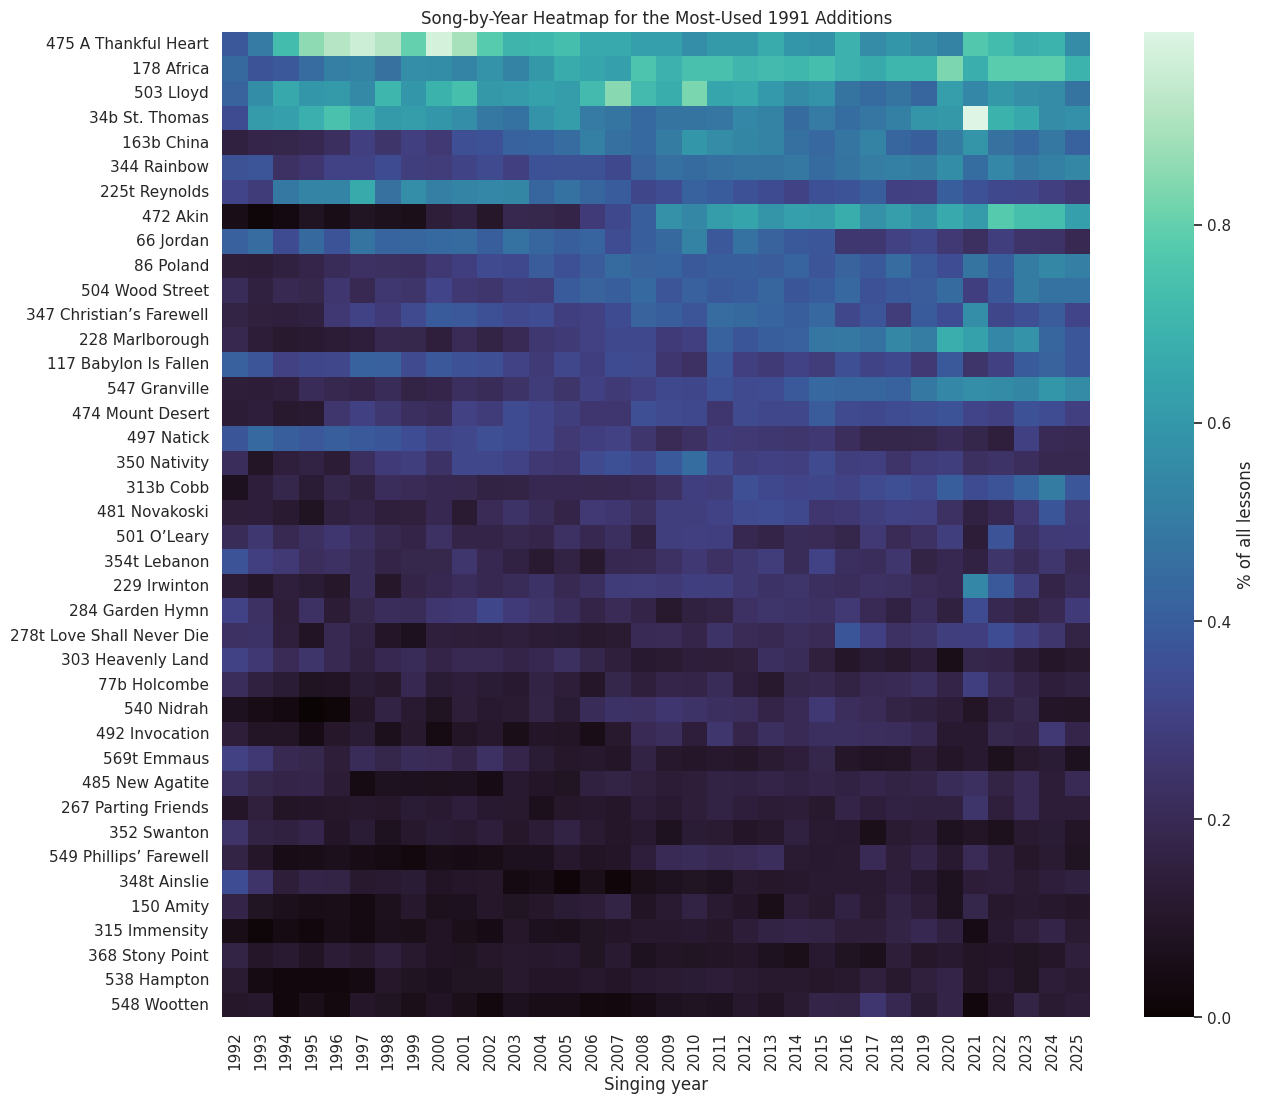

In [79]:
# @title
heat = song_year_counts.merge(top_new_songs.head(40)[["song_id"]], on="song_id")
heat["song_label"] = heat.page_num + " " + heat.title
pivot = heat.pivot_table(index="song_label", columns="singing_year", values="share_of_all_lessons", fill_value=0)
pivot = pivot.loc[heat.groupby("song_label").lessons.sum().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, max(6, len(pivot) * 0.32)))
if sns:
    sns.heatmap(pivot * 100, cmap="mako", ax=ax, cbar_kws={"label": "% of all lessons"})
else:
    im = ax.imshow(pivot * 100, aspect="auto")
    ax.set_yticks(range(len(pivot.index)), pivot.index)
    ax.set_xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
    fig.colorbar(im, ax=ax, label="% of all lessons")
ax.set_title("Song-by-Year Heatmap for the Most-Used 1991 Additions")
ax.set_xlabel("Singing year")
ax.set_ylabel("")
plt.show()

## Did Some Songs Start Fast While Others Rose Later?

In [80]:
# @title
def era_total_for_song(start, end):
    mask = song_year_counts.singing_year.between(start, end)
    return song_year_counts[mask].groupby("song_id").lessons.sum()

early = era_total_for_song(1992, 1999)
middle = era_total_for_song(2000, 2010)
late = era_total_for_song(2011, int(lesson_facts.singing_year.max()))

rise = new_songs[["song_id", "page_num", "title"]].copy()
rise["early_lessons"] = rise.song_id.map(early).fillna(0).astype(int)
rise["middle_lessons"] = rise.song_id.map(middle).fillna(0).astype(int)
rise["late_lessons"] = rise.song_id.map(late).fillna(0).astype(int)
rise["late_minus_early"] = rise.late_lessons - rise.early_lessons
rise["early_share_of_song"] = rise.early_lessons / rise[["early_lessons", "middle_lessons", "late_lessons"]].sum(axis=1).replace(0, np.nan)
rise.sort_values("early_lessons", ascending=False).head(12)

,song_id,page_num,title,early_lessons,middle_lessons,late_lessons,late_minus_early,early_share_of_song
40,549,475,A Thankful Heart,862,1327,1533,671,0.231596
0,17,34b,St. Thomas,698,959,1340,642,0.232900
48,591,503,Lloyd,667,1305,1346,679,0.201025
10,264,225t,Reynolds,548,826,841,293,0.247404
9,214,178,Africa,528,1185,1790,1262,0.150728
3,67,66,Jordan,474,803,802,328,0.227994
46,581,497,Natick,442,537,564,122,0.286455
6,139,117,Babylon Is Fallen,412,583,812,400,0.228002
22,387,344,Rainbow,351,679,1225,874,0.155654
29,400,354t,Lebanon,277,353,580,303,0.228926


In [81]:
rise.sort_values("late_minus_early", ascending=False).head(12)

,song_id,page_num,title,early_lessons,middle_lessons,late_lessons,late_minus_early,early_share_of_song
38,546,472,Akin,63,541,1583,1520,0.028807
9,214,178,Africa,528,1185,1790,1262,0.150728
11,267,228,Marlborough,170,480,1164,994,0.093716
8,197,163b,China,252,822,1186,934,0.111504
54,641,547,Granville,194,499,1104,910,0.107958
22,387,344,Rainbow,351,679,1225,874,0.155654
5,102,86,Poland,213,690,1056,843,0.108729
49,592,504,Wood Street,244,658,1018,774,0.127083
23,391,347,Christian’s Farewell,258,669,951,693,0.137380
20,351,313b,Cobb,182,376,868,686,0.127630


## Overall Yearly Use Of 1991 Songs Removed in 2025

In [82]:
# @title
removed_song_pages = read_1991_new_songs(REMOVED_SONGS_PATH)
removed_song_pages["page_num"] = removed_song_pages.page_num.str.rstrip("*")

removed_songs = removed_song_pages.merge(songs_1991, on="page_num", how="left")
missing_removed = removed_songs[removed_songs.song_id.isna()]
assert missing_removed.empty, missing_removed
removed_songs["song_id"] = removed_songs["song_id"].astype(int)
removed_song_ids = set(removed_songs.song_id)

lesson_facts["is_1991_removed_2025"] = lesson_facts.song_id.isin(removed_song_ids)

year_removed = lesson_facts[lesson_facts.is_1991_removed_2025].groupby("singing_year").agg(
    removed_song_lessons=("song_id", "size"),
    records_with_removed_song=("minutes_id", "nunique"),
)

yearly_removed = year_total.join(year_removed, how="left").fillna(0)
yearly_removed["share_of_lessons"] = yearly_removed.removed_song_lessons / yearly_removed.total_lessons
yearly_removed["share_of_records"] = yearly_removed.records_with_removed_song / yearly_removed.singing_records
yearly_removed = yearly_removed.reset_index()
yearly_removed.head()

,singing_year,total_lessons,singing_records,removed_song_lessons,records_with_removed_song,share_of_lessons,share_of_records
0,1992,13847,151,500,124,0.036109,0.821192
1,1993,14211,162,487,134,0.034269,0.827160
2,1994,14344,162,481,135,0.033533,0.833333
3,1995,13647,164,357,134,0.026160,0.817073
4,1996,13858,165,342,131,0.024679,0.793939


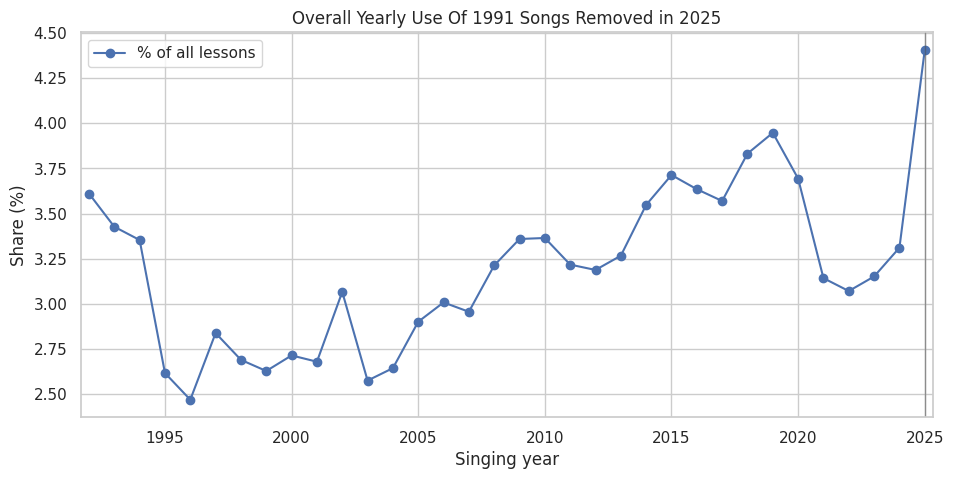

In [83]:
# @title
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly_removed.singing_year, yearly_removed.share_of_lessons * 100, marker="o", label="% of all lessons")
ax.axvline(2025, color="0.3", lw=1, alpha=0.5)
ax.set_title("Overall Yearly Use Of 1991 Songs Removed in 2025")
ax.set_xlabel("Singing year")
ax.set_ylabel("Share (%)")
ax.legend()
ax.margins(x=0.01)
plt.show()

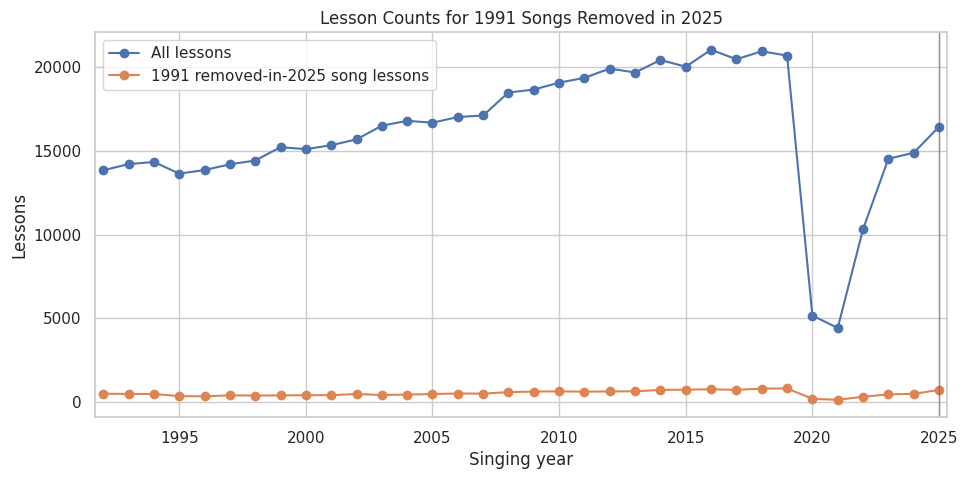

In [84]:
# @title
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly_removed.singing_year, yearly_removed.total_lessons, marker="o", label="All lessons")
ax.plot(yearly_removed.singing_year, yearly_removed.removed_song_lessons, marker="o", label="1991 removed-in-2025 song lessons")
ax.axvline(2025, color="0.3", lw=1, alpha=0.5)
ax.set_title("Lesson Counts for 1991 Songs Removed in 2025")
ax.set_xlabel("Singing year")
ax.set_ylabel("Lessons")
ax.legend()
ax.margins(x=0.01)
plt.show()

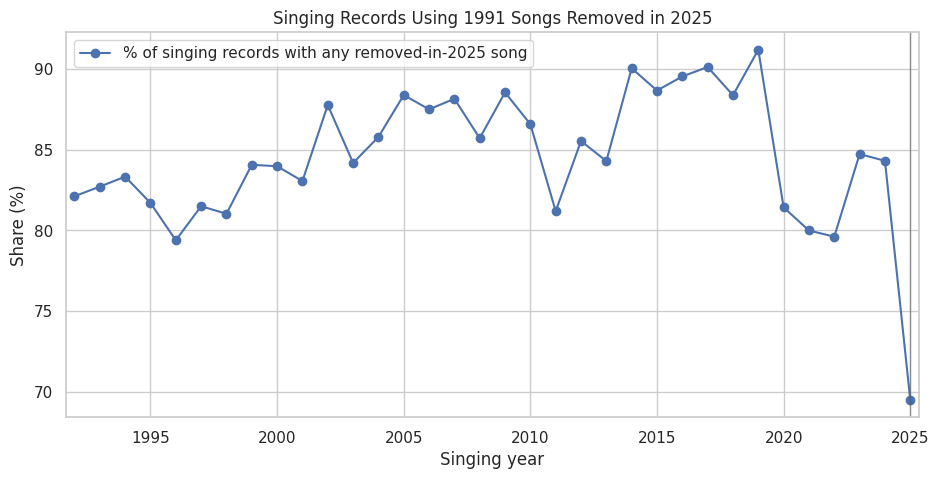

In [85]:
# @title
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly_removed.singing_year, yearly_removed.share_of_records * 100, marker="o", label="% of singing records with any removed-in-2025 song")
ax.axvline(2025, color="0.3", lw=1, alpha=0.5)
ax.set_title("Singing Records Using 1991 Songs Removed in 2025")
ax.set_xlabel("Singing year")
ax.set_ylabel("Share (%)")
ax.legend()
ax.margins(x=0.01)
plt.show()

## Song-By-Song Trajectories of 1991 Songs Removed From 2025

In [86]:
# @title
removed_song_year_counts = lesson_facts[lesson_facts.song_id.isin(removed_song_ids)].groupby(["song_id", "singing_year"]).agg(
    lessons=("song_id", "size"),
    singing_records=("minutes_id", "nunique"),
).reset_index()
removed_song_year_counts = removed_song_year_counts.merge(year_total.reset_index(), on="singing_year", how="left")
removed_song_year_counts = removed_song_year_counts.merge(removed_songs[["song_id", "page_num", "title"]], on="song_id", how="left")
removed_song_year_counts["share_of_all_lessons"] = removed_song_year_counts.lessons / removed_song_year_counts.total_lessons
removed_song_year_counts["share_of_records"] = removed_song_year_counts.singing_records_x / removed_song_year_counts.singing_records_y
removed_song_year_counts = removed_song_year_counts.rename(columns={"singing_records_x": "song_records", "singing_records_y": "all_records"})

top_removed_songs = (removed_song_year_counts.groupby(["song_id", "page_num", "title"]).lessons.sum()
                     .sort_values(ascending=False).head(40).reset_index())
top_removed_songs

,song_id,page_num,title,lessons
0,603,515,Federal Street,1060
1,612,523,Pleyel’s Hymn,744
2,283,254,Rose of Sharon,649
3,376,334,O Come Away,637
4,362,323b,Soft Music,564
5,572,491,"Oh, What Love",437
6,501,438,The Marriage in the Skies,408
7,45,50b,Humility,392
8,577,494,Big Creek,378
9,472,415,Easter Morn,373


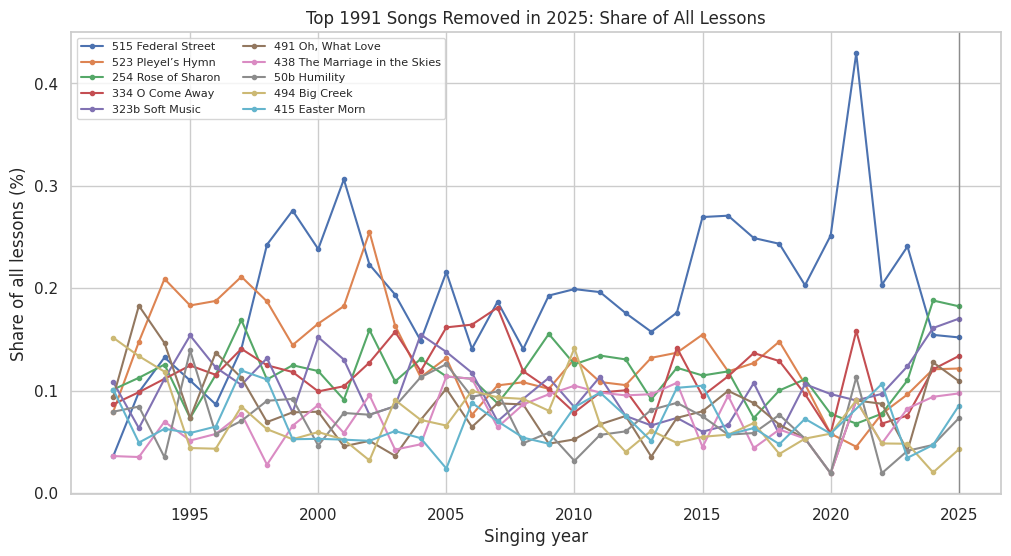

In [87]:
# @title
fig, ax = plt.subplots(figsize=(12, 6))
for _, song in top_removed_songs.head(10).iterrows():
    group = removed_song_year_counts[removed_song_year_counts.song_id == song.song_id]
    label = f"{song.page_num} {song.title}"
    ax.plot(group.singing_year, group.share_of_all_lessons * 100, marker="o", ms=3, label=label)
ax.axvline(2025, color="0.3", lw=1, alpha=0.5)
ax.set_title("Top 1991 Songs Removed in 2025: Share of All Lessons")
ax.set_xlabel("Singing year")
ax.set_ylabel("Share of all lessons (%)")
ax.legend(fontsize=8, ncol=2)
plt.show()

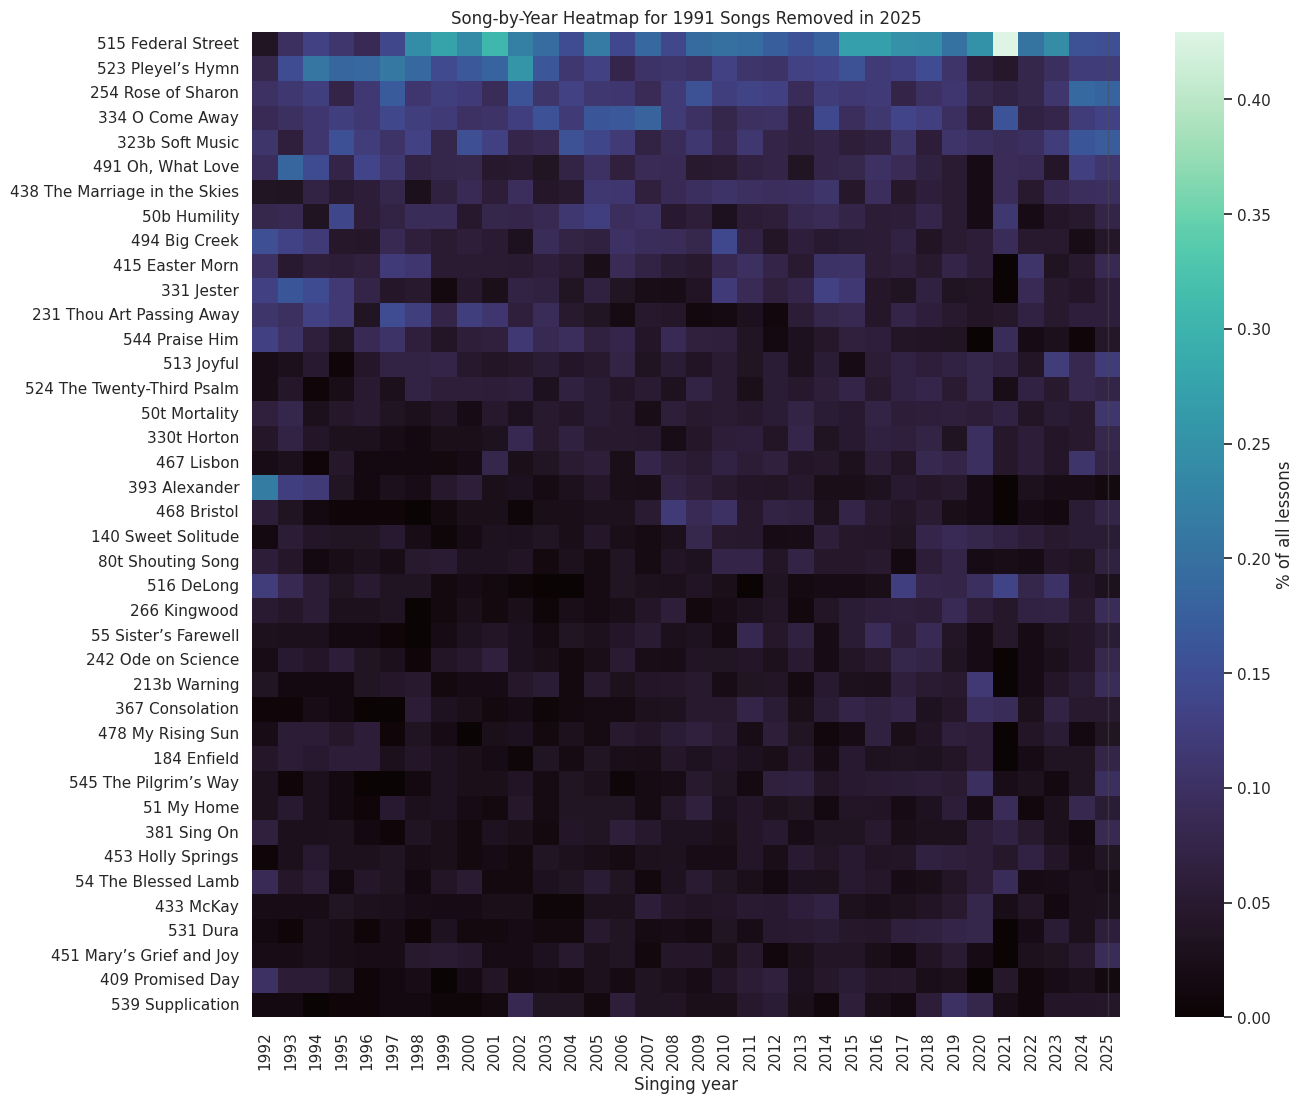

In [88]:
# @title
removed_heat = removed_song_year_counts.merge(top_removed_songs.head(40)[["song_id"]], on="song_id")
removed_heat["song_label"] = removed_heat.page_num + " " + removed_heat.title
removed_pivot = removed_heat.pivot_table(index="song_label", columns="singing_year", values="share_of_all_lessons", fill_value=0)
removed_pivot = removed_pivot.loc[removed_heat.groupby("song_label").lessons.sum().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, max(6, len(removed_pivot) * 0.32)))
if sns:
    sns.heatmap(removed_pivot * 100, cmap="mako", ax=ax, cbar_kws={"label": "% of all lessons"})
else:
    im = ax.imshow(removed_pivot * 100, aspect="auto")
    ax.set_yticks(range(len(removed_pivot.index)), removed_pivot.index)
    ax.set_xticks(range(len(removed_pivot.columns)), removed_pivot.columns, rotation=90)
    fig.colorbar(im, ax=ax, label="% of all lessons")
ax.axvline(len(removed_pivot.columns) - 0.5, color="0.3", lw=1, alpha=0.5)
ax.set_title("Song-by-Year Heatmap for 1991 Songs Removed in 2025")
ax.set_xlabel("Singing year")
ax.set_ylabel("")
plt.show()

## Regional Popularity Across Co-Attendance Regions

If `singing_neighborhood_regions.csv` exists, this section uses the canonical minutes-to-singing mapping in `Singings.csv` to attach each lesson to the co-attendance regions from the singing-neighborhood analysis.

The main balance score compares a song's observed regional lesson distribution with the background distribution of all lessons across those same regions. A score near 1 means the song follows the overall regional opportunity pattern; a score near 0 means its use is regionally concentrated.

In [89]:
# @title
REGIONS_PATH = Path("singing_neighborhood_regions.csv")
REGION_NAMES_PATH = Path("singing_neighborhood_region_names.csv")
SINGINGS_MAP_PATH = Path("Singings.csv")

MIN_REGION_SONG_LESSONS = 8
MIN_ASSOCIATION_LESSONS_IN_REGION = 3
MIN_ASSOCIATION_LIFT = 2.0

if not REGIONS_PATH.exists():
    print(f"Skipping regional analysis: {REGIONS_PATH} does not exist.")
elif not SINGINGS_MAP_PATH.exists():
    print(f"Skipping regional analysis: {SINGINGS_MAP_PATH} does not exist.")
else:
    region_assignments = pd.read_csv(REGIONS_PATH)
    region_names = pd.read_csv(REGION_NAMES_PATH) if REGION_NAMES_PATH.exists() else None
    singing_map = pd.read_csv(SINGINGS_MAP_PATH)

    singing_map["canonical_singing"] = (
        singing_map["corrected_singing"]
        .fillna(singing_map["singing"])
        .astype(str)
        .str.strip()
    )
    singing_map = singing_map[
        singing_map["id"].notna()
        & singing_map["canonical_singing"].notna()
        & singing_map["canonical_singing"].ne("")
        & singing_map["canonical_singing"].ne("nan")
    ].copy()
    singing_map["minutes_id"] = singing_map["id"].astype(int)
    mapped_minutes = singing_map[["minutes_id", "canonical_singing"]].drop_duplicates()

    region_lookup = region_assignments[["singing", "region_id", "region_size", "mapped_minutes", "distinct_leaders"]].copy()
    minute_regions = mapped_minutes.merge(
        region_lookup,
        left_on="canonical_singing",
        right_on="singing",
        how="inner",
    )
    minute_regions = minute_regions[["minutes_id", "canonical_singing", "region_id", "region_size"]].drop_duplicates()

    fallback_region_labels = (
        region_assignments.sort_values(["region_id", "mapped_minutes"], ascending=[True, False])
        .groupby("region_id")
        .head(3)
        .groupby("region_id")["singing"]
        .apply(lambda values: "; ".join(values))
        .rename("region_label")
    )
    if region_names is not None:
        region_labels = (
            region_names.set_index("region_id")["region_name"]
            .rename("region_label")
            .combine_first(fallback_region_labels)
        )
    else:
        region_labels = fallback_region_labels

    regional_lesson_facts = lesson_facts.merge(minute_regions, on="minutes_id", how="inner")
    regional_lesson_facts = regional_lesson_facts.drop_duplicates(
        ["minutes_id", "lesson_id", "song_id", "region_id"]
    )

    mapped_minutes_count = regional_lesson_facts["minutes_id"].nunique()
    all_minutes_count = lesson_facts["minutes_id"].nunique()
    print(f"regional mapped minutes with lessons: {mapped_minutes_count:,} of {all_minutes_count:,} ({mapped_minutes_count / all_minutes_count:.1%})")
    print(f"regions represented: {regional_lesson_facts['region_id'].nunique():,}")

    region_totals = regional_lesson_facts.groupby("region_id").agg(
        region_total_lessons=("song_id", "size"),
        region_singing_records=("minutes_id", "nunique"),
    )
    region_totals = region_totals.join(region_labels, how="left")
    region_totals["background_lesson_share"] = region_totals.region_total_lessons / region_totals.region_total_lessons.sum()

    display(region_totals.sort_values("region_total_lessons", ascending=False).head(12))


regional mapped minutes with lessons: 6,179 of 6,739 (91.7%)
regions represented: 68


,region_total_lessons,region_singing_records,region_label,background_lesson_share
region_id,,,,
S004,59088,460,Northeast Alabama,0.115196
S001,41941,408,West Georgia,0.081767
S007,29877,354,Upper Midwest,0.058247
S008,25854,249,New England and Eastern Canada,0.050404
S027,23894,261,"Walker County, Alabama",0.046583
S009,23378,214,Mid-Atlantic,0.045577
S006,22626,354,East Alabama and West Georgia,0.044111
S002,20864,291,Northwest Alabama,0.040676
S003,20634,201,British Isles and Europe,0.040227


### Balance Score

`regional_balance_score` is `1 - normalized Jensen-Shannon distance` between a song's regional lesson distribution and the all-lesson regional background. It is weighted for different region sizes, so a broadly popular song is not penalized merely because large regions have more total lessons.

Companion columns make the score easier to read:

- `top_region_lesson_share`: share of the song's mapped regional lessons in its strongest single region.
- `effective_regions`: entropy-based count of regions implied by the observed distribution.
- `max_lift`: strongest regional over-representation compared with the background expectation.

In [90]:
# @title
def normalized_js_balance(observed_counts: pd.Series, background_probs: pd.Series) -> float:
    observed = observed_counts.reindex(background_probs.index, fill_value=0).astype(float)
    if observed.sum() <= 0:
        return np.nan
    p = observed / observed.sum()
    q = background_probs.astype(float) / background_probs.sum()
    m = 0.5 * (p + q)

    def kl(left, right):
        mask = left > 0
        return float((left[mask] * np.log(left[mask] / right[mask])).sum())

    js_divergence = 0.5 * kl(p, m) + 0.5 * kl(q, m)
    js_distance = np.sqrt(js_divergence)
    max_distance = np.sqrt(np.log(2))
    return 1 - (js_distance / max_distance)


def effective_region_count(counts: pd.Series) -> float:
    counts = counts[counts > 0].astype(float)
    if counts.empty:
        return np.nan
    probs = counts / counts.sum()
    return float(np.exp(-(probs * np.log(probs)).sum()))


if REGIONS_PATH.exists() and SINGINGS_MAP_PATH.exists():
    new_song_region_counts = (
        regional_lesson_facts[regional_lesson_facts.song_id.isin(new_song_ids)]
        .groupby(["song_id", "region_id"])
        .agg(
            song_region_lessons=("song_id", "size"),
            song_region_records=("minutes_id", "nunique"),
            song_region_singings=("canonical_singing", "nunique"),
        )
        .reset_index()
    )

    new_song_region_counts = new_song_region_counts.merge(region_totals.reset_index(), on="region_id", how="left")
    new_song_region_counts["regional_share_of_lessons"] = (
        new_song_region_counts.song_region_lessons / new_song_region_counts.region_total_lessons
    )

    total_regional_lessons = region_totals.region_total_lessons.sum()
    song_totals = new_song_region_counts.groupby("song_id").song_region_lessons.sum().rename("mapped_regional_lessons")
    new_song_region_counts = new_song_region_counts.merge(song_totals, on="song_id", how="left")
    new_song_region_counts["expected_lessons_if_balanced"] = (
        new_song_region_counts.mapped_regional_lessons
        * new_song_region_counts.region_total_lessons
        / total_regional_lessons
    )
    new_song_region_counts["lift_vs_regional_background"] = (
        new_song_region_counts.song_region_lessons / new_song_region_counts.expected_lessons_if_balanced
    )

    background_probs = region_totals["background_lesson_share"]
    balance_rows = []
    for song_id, group in new_song_region_counts.groupby("song_id"):
        counts = group.set_index("region_id")["song_region_lessons"]
        top_row = group.sort_values(
            ["song_region_lessons", "lift_vs_regional_background"],
            ascending=False,
        ).iloc[0]
        lift_regions = group[
            (group.song_region_lessons >= MIN_ASSOCIATION_LESSONS_IN_REGION)
            & (group.lift_vs_regional_background >= MIN_ASSOCIATION_LIFT)
        ].sort_values("lift_vs_regional_background", ascending=False)
        balance_rows.append({
            "song_id": song_id,
            "mapped_regional_lessons": int(counts.sum()),
            "regions_with_lessons": int((counts > 0).sum()),
            "effective_regions": effective_region_count(counts),
            "regional_balance_score": normalized_js_balance(counts, background_probs),
            "top_region_id": top_row.region_id,
            "top_region_label": top_row.region_label,
            "top_region_lessons": int(top_row.song_region_lessons),
            "top_region_lesson_share": top_row.song_region_lessons / counts.sum(),
            "max_lift": float(group.lift_vs_regional_background.max()),
            "associated_region_count": int(lift_regions.region_id.nunique()),
            "associated_regions": "; ".join(
                f"{row.region_id} ({row.lift_vs_regional_background:.1f}x, n={int(row.song_region_lessons)})"
                for row in lift_regions.itertuples()
            ),
        })

    song_region_balance = pd.DataFrame(balance_rows).merge(
        new_songs[["song_id", "page_num", "title"]],
        on="song_id",
        how="left",
    )
    song_region_balance = song_region_balance[
        song_region_balance.mapped_regional_lessons >= MIN_REGION_SONG_LESSONS
    ].sort_values("regional_balance_score", ascending=False)

    display_cols = [
        "page_num", "title",
        "mapped_regional_lessons", "regions_with_lessons",
        "effective_regions", "regional_balance_score",
        "top_region_id", "top_region_label", "top_region_lesson_share",
        "associated_region_count", "associated_regions",
        "max_lift"
    ]
    display(song_region_balance[display_cols].head(15))


,page_num,title,mapped_regional_lessons,regions_with_lessons,effective_regions,regional_balance_score,top_region_id,top_region_label,top_region_lesson_share,associated_region_count,associated_regions,max_lift
40,475,A Thankful Heart,3525,62,26.161832,0.872524,S004,Northeast Alabama,0.122837,2,"S071 (2.6x, n=4); S108 (2.3x, n=7)",2.645694
48,503,Lloyd,3099,64,29.570159,0.861033,S001,West Georgia,0.099064,9,"S071 (3.0x, n=4); S078 (2.5x, n=8); S073 (2.5x...",3.009381
0,34b,St. Thomas,2802,61,30.832608,0.849741,S007,Upper Midwest,0.075660,7,"S108 (6.7x, n=16); S107 (3.2x, n=3); S092 (3.0...",6.748754
38,472,Akin,2010,59,27.921705,0.814756,S004,Northeast Alabama,0.114925,8,"S067 (4.4x, n=14); S052 (3.5x, n=24); S115 (3....",4.443625
3,66,Jordan,1941,59,28.077890,0.808336,S007,Upper Midwest,0.091705,6,"S093 (3.5x, n=9); S033 (3.1x, n=11); S078 (3.0...",3.533974
18,284,Garden Hymn,1091,48,25.314675,0.799872,S001,West Georgia,0.126489,4,"S068 (7.3x, n=4); S030 (3.5x, n=14); S033 (2.5...",7.346099
17,278t,Love Shall Never Die,985,53,27.635465,0.797984,S004,Northeast Alabama,0.111675,8,"S119 (5.3x, n=5); S089 (4.3x, n=3); S104 (3.4x...",5.324593
53,540,Nidrah,836,46,24.982165,0.796334,S004,Northeast Alabama,0.154306,7,"S096 (4.1x, n=4); S114 (4.0x, n=3); S030 (3.9x...",5.091763
29,354t,Lebanon,1127,53,28.672380,0.790613,S001,West Georgia,0.126886,5,"S104 (5.3x, n=7); S025 (3.6x, n=46); S096 (3.1...",5.274711
12,229,Irwinton,1136,52,26.801133,0.788406,S001,West Georgia,0.117958,4,"S038 (3.4x, n=14); S025 (3.1x, n=40); S006 (2....",3.569379


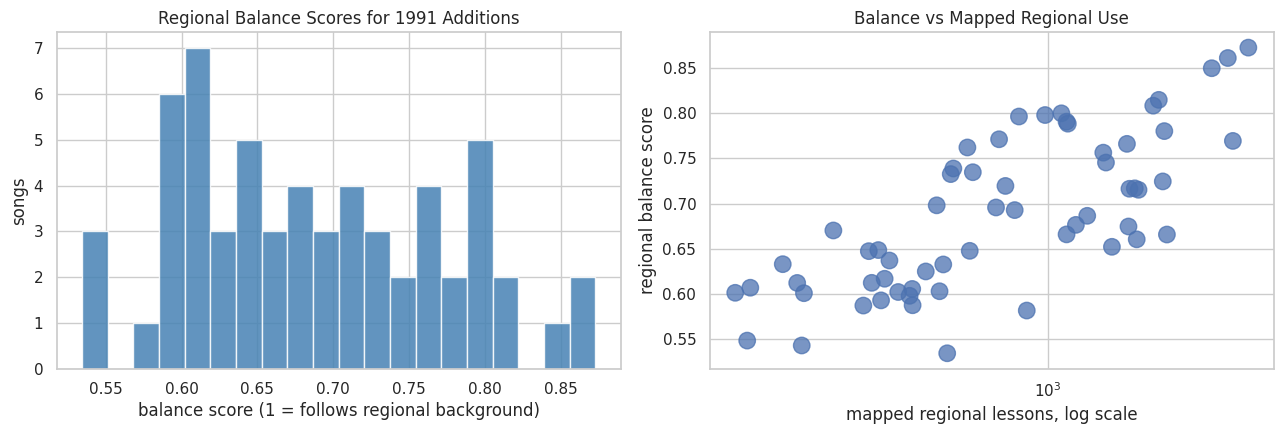

In [91]:
# @title
if REGIONS_PATH.exists() and SINGINGS_MAP_PATH.exists():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].hist(song_region_balance.regional_balance_score.dropna(), bins=20, color="steelblue", alpha=0.85)
    axes[0].set_title("Regional Balance Scores for 1991 Additions")
    axes[0].set_xlabel("balance score (1 = follows regional background)")
    axes[0].set_ylabel("songs")

    axes[1].scatter(
        song_region_balance.mapped_regional_lessons,
        song_region_balance.regional_balance_score,
        s=np.clip(song_region_balance.regions_with_lessons * 9, 20, 140),
        alpha=0.75,
    )
    axes[1].set_xscale("log")
    axes[1].set_title("Balance vs Mapped Regional Use")
    axes[1].set_xlabel("mapped regional lessons, log scale")
    axes[1].set_ylabel("regional balance score")

    plt.tight_layout()
    plt.show()


## Global Acceptance Of 1991 Additions

These views treat the 1991 additions as a song set rather than as individual songs. The aim is to see whether the new songs became broadly accepted across co-attendance regions, whether adoption varied sharply by region, and whether regions used a broad slice of the new repertory or only a few favorites.

### Regional Penetration Over Time

This summarizes each era by asking how many mapped regions used any 1991-added song, and how much of each region's singing was made up of 1991 additions. The heatmap then shows the same adoption pattern region by region.

In [92]:
# @title
if REGIONS_PATH.exists() and SINGINGS_MAP_PATH.exists():
    # acceptance_bins = [1990, 1994, 1999, 2009, 2019, 2100]
    # acceptance_labels = ["1992-1994", "1995-1999", "2000-2009", "2010-2019", "2020+"]

    acceptance_bins = [1990, 1994, 1999, 2004, 2009, 2014, 2019, 2100]
    acceptance_labels = ["1992-1994", "1995-1999", "2000-2004", "2005-2009", "2010-2014", "2015-2019", "2020+"]

    regional_acceptance_facts = regional_lesson_facts.dropna(subset=["singing_year"]).copy()
    regional_acceptance_facts["singing_year"] = regional_acceptance_facts["singing_year"].astype(int)
    regional_acceptance_facts["era"] = pd.cut(
        regional_acceptance_facts.singing_year,
        bins=acceptance_bins,
        labels=acceptance_labels,
    )
    regional_acceptance_facts["is_1991_new"] = regional_acceptance_facts.song_id.isin(new_song_ids)

    region_era_acceptance = regional_acceptance_facts.groupby(["region_id", "era"], observed=True).agg(
        total_lessons=("song_id", "size"),
        new_song_lessons=("is_1991_new", "sum"),
        singing_records=("minutes_id", "nunique"),
        new_songs_used=("song_id", lambda values: values[values.isin(new_song_ids)].nunique()),
    ).reset_index()
    region_era_acceptance["new_song_lesson_share"] = (
        region_era_acceptance.new_song_lessons / region_era_acceptance.total_lessons
    )
    region_era_acceptance["used_any_new_song"] = region_era_acceptance.new_song_lessons.gt(0)

    global_acceptance_era_summary = region_era_acceptance.groupby("era", observed=True).agg(
        regions_with_minutes=("region_id", "nunique"),
        regions_using_new_songs=("used_any_new_song", "sum"),
        total_lessons=("total_lessons", "sum"),
        new_song_lessons=("new_song_lessons", "sum"),
        median_region_new_song_share=("new_song_lesson_share", "median"),
        mean_region_new_song_share=("new_song_lesson_share", "mean"),
        median_new_songs_used=("new_songs_used", "median"),
    )
    global_acceptance_era_summary["pct_regions_using_new_songs"] = (
        global_acceptance_era_summary.regions_using_new_songs
        / global_acceptance_era_summary.regions_with_minutes
    )
    global_acceptance_era_summary["overall_new_song_lesson_share"] = (
        global_acceptance_era_summary.new_song_lessons
        / global_acceptance_era_summary.total_lessons
    )

    display(global_acceptance_era_summary[
        [
            "regions_with_minutes", "regions_using_new_songs", "pct_regions_using_new_songs",
            "overall_new_song_lesson_share", "median_region_new_song_share",
            "mean_region_new_song_share", "median_new_songs_used",
        ]
    ].style.format({
        "pct_regions_using_new_songs": "{:.1%}",
        "overall_new_song_lesson_share": "{:.2%}",
        "median_region_new_song_share": "{:.2%}",
        "mean_region_new_song_share": "{:.2%}",
        "median_new_songs_used": "{:.0f}",
    }))


,regions_with_minutes,regions_using_new_songs,pct_regions_using_new_songs,overall_new_song_lesson_share,median_region_new_song_share,mean_region_new_song_share,median_new_songs_used
era,,,,,,,
1992-1994,29,29,100.0%,9.90%,11.65%,10.94%,33
1995-1999,38,38,100.0%,10.02%,10.79%,11.54%,29
2000-2004,40,40,100.0%,10.71%,11.49%,11.46%,36
2005-2009,48,48,100.0%,11.86%,12.99%,12.51%,36
2010-2014,56,56,100.0%,13.16%,13.99%,13.21%,32
2015-2019,51,51,100.0%,13.17%,14.74%,14.21%,38
2020+,43,43,100.0%,13.33%,14.42%,14.69%,35


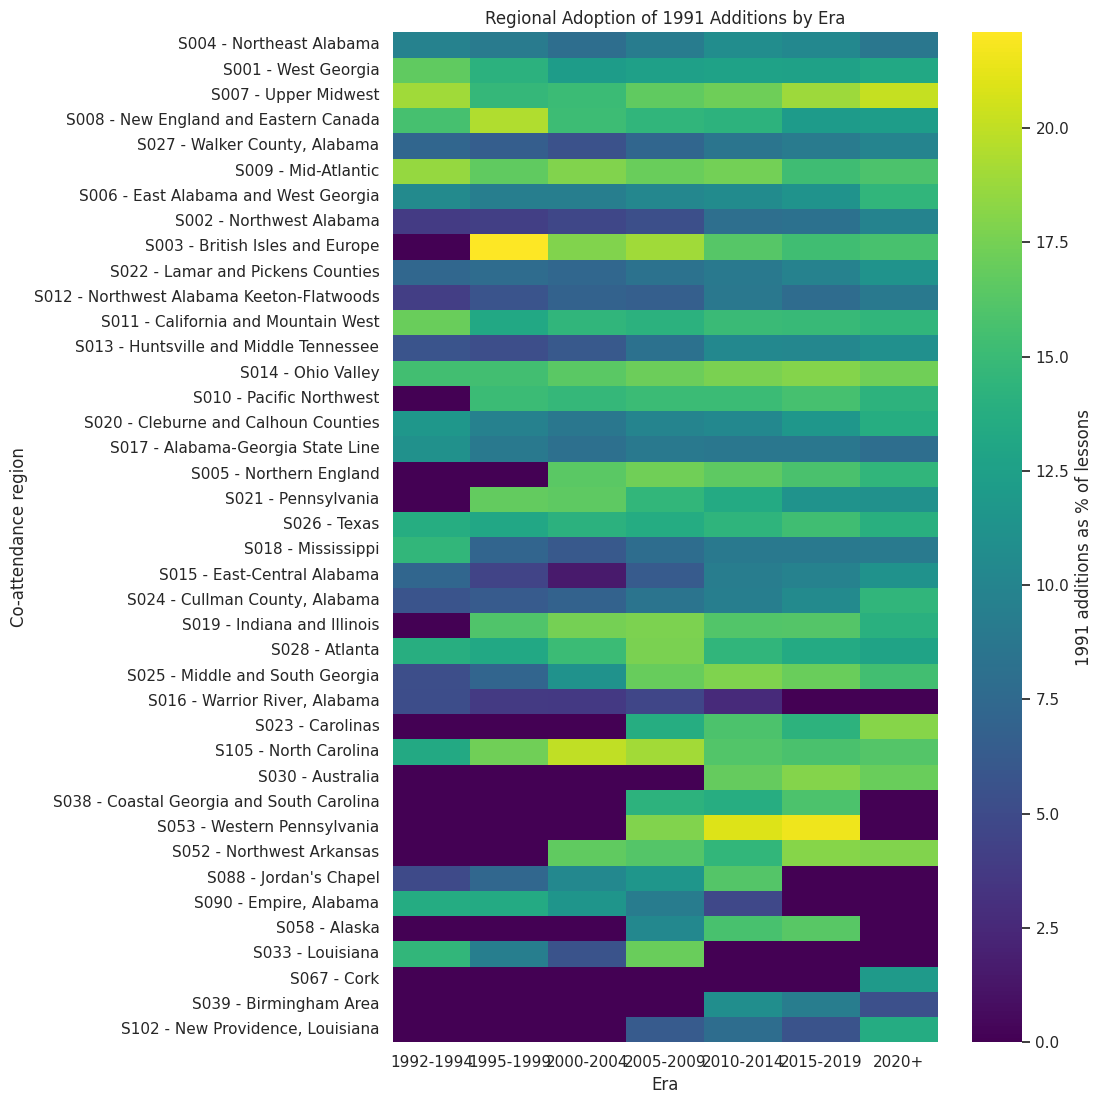

In [93]:
# @title
if REGIONS_PATH.exists() and SINGINGS_MAP_PATH.exists():
    heatmap_regions = (
        region_totals.sort_values("region_total_lessons", ascending=False)
        .head(40)
        .index
    )
    heatmap_data = region_era_acceptance[
        region_era_acceptance.region_id.isin(heatmap_regions)
    ].copy()
    heatmap_data = heatmap_data.merge(region_labels.reset_index(), on="region_id", how="left")
    heatmap_data["region_display"] = heatmap_data.region_id + " - " + heatmap_data.region_label.str.slice(0, 65)

    heatmap_pivot = heatmap_data.pivot_table(
        index="region_display",
        columns="era",
        values="new_song_lesson_share",
        fill_value=0,
        observed=True,
    )
    ordered_region_ids = region_totals.loc[heatmap_regions].sort_values("region_total_lessons", ascending=False).index
    region_display_order = (
        heatmap_data[["region_id", "region_display"]]
        .drop_duplicates()
        .set_index("region_id")
        .loc[ordered_region_ids, "region_display"]
    )
    heatmap_pivot = heatmap_pivot.reindex(region_display_order)

    fig, ax = plt.subplots(figsize=(11, max(8, len(heatmap_pivot) * 0.28)))
    sns.heatmap(
        heatmap_pivot * 100,
        cmap="viridis",
        ax=ax,
        cbar_kws={"label": "1991 additions as % of lessons"},
    )
    ax.set_title("Regional Adoption of 1991 Additions by Era")
    ax.set_xlabel("Era")
    ax.set_ylabel("Co-attendance region")
    plt.tight_layout()
    plt.show()


### Acceptance Distribution By Region

Each point is one co-attendance region. This shows whether acceptance of the 1991 additions was broadly similar across regions or driven by a few heavy-adopting regions.

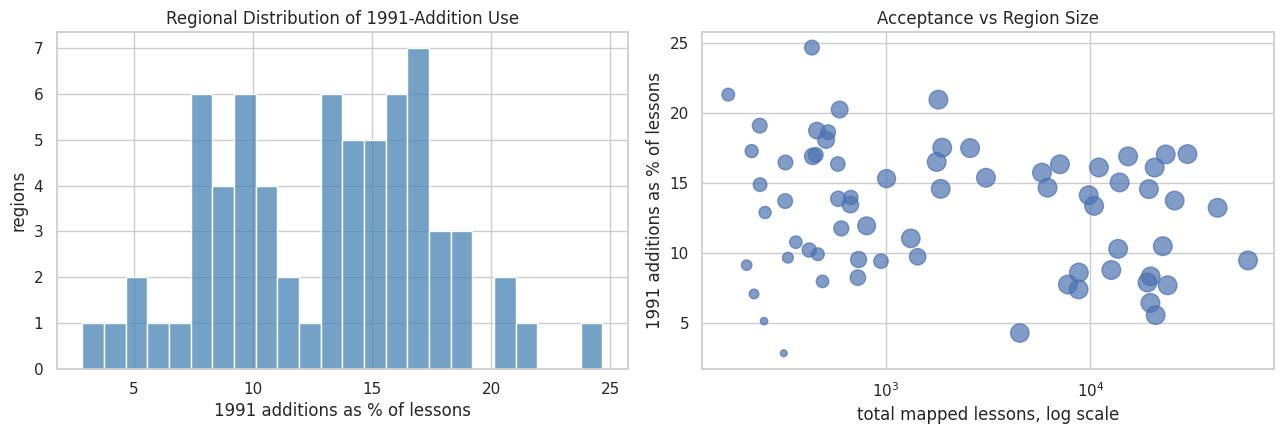

,region_label,total_lessons,new_song_lessons,new_song_lesson_share,new_songs_used,new_songs_used_pct
region_id,,,,,,
S108,Old Songs,434,107,24.65%,28,46.7%
S107,Norumbega,169,36,21.30%,21,35.0%
S053,Western Pennsylvania,1805,378,20.94%,51,85.0%
S096,East Atlanta,593,120,20.24%,36,60.0%
S092,Marian Bush Memorial,241,46,19.09%,28,46.7%
S114,Pikes Peak,459,86,18.74%,35,58.3%
S078,Feast and FaSoLa,521,97,18.62%,28,46.7%
S074,Duluth,509,92,18.07%,37,61.7%
S030,Australia,1884,330,17.52%,45,75.0%


In [94]:
# @title
if REGIONS_PATH.exists() and SINGINGS_MAP_PATH.exists():
    region_acceptance_summary = regional_acceptance_facts.groupby("region_id").agg(
        total_lessons=("song_id", "size"),
        new_song_lessons=("is_1991_new", "sum"),
        singing_records=("minutes_id", "nunique"),
        new_songs_used=("song_id", lambda values: values[values.isin(new_song_ids)].nunique()),
    )
    region_acceptance_summary["new_song_lesson_share"] = (
        region_acceptance_summary.new_song_lessons / region_acceptance_summary.total_lessons
    )
    region_acceptance_summary["new_songs_used_pct"] = region_acceptance_summary.new_songs_used / len(new_song_ids)
    region_acceptance_summary = region_acceptance_summary.join(region_labels, how="left")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    sns.histplot(region_acceptance_summary.new_song_lesson_share * 100, bins=24, ax=axes[0], color="steelblue")
    axes[0].set_title("Regional Distribution of 1991-Addition Use")
    axes[0].set_xlabel("1991 additions as % of lessons")
    axes[0].set_ylabel("regions")

    plot_df = region_acceptance_summary.reset_index()
    axes[1].scatter(
        plot_df.total_lessons,
        plot_df.new_song_lesson_share * 100,
        s=np.clip(plot_df.new_songs_used * 4, 18, 180),
        alpha=0.7,
    )
    axes[1].set_xscale("log")
    axes[1].set_title("Acceptance vs Region Size")
    axes[1].set_xlabel("total mapped lessons, log scale")
    axes[1].set_ylabel("1991 additions as % of lessons")

    plt.tight_layout()
    plt.show()

    display(region_acceptance_summary.sort_values(
        ["new_song_lesson_share", "total_lessons"],
        ascending=False,
    )[
        ["region_label", "total_lessons", "new_song_lessons", "new_song_lesson_share", "new_songs_used", "new_songs_used_pct"]
    ].head(15).style.format({
        "new_song_lesson_share": "{:.2%}",
        "new_songs_used_pct": "{:.1%}",
    }))


### Song-Set Coverage By Region

This asks whether regions adopted a broad slice of the 1991 additions or concentrated on a smaller subset. `effective_new_song_count` is entropy-based: it is high when a region's 1991-added-song lessons are spread across many songs, and lower when a few favorites dominate.

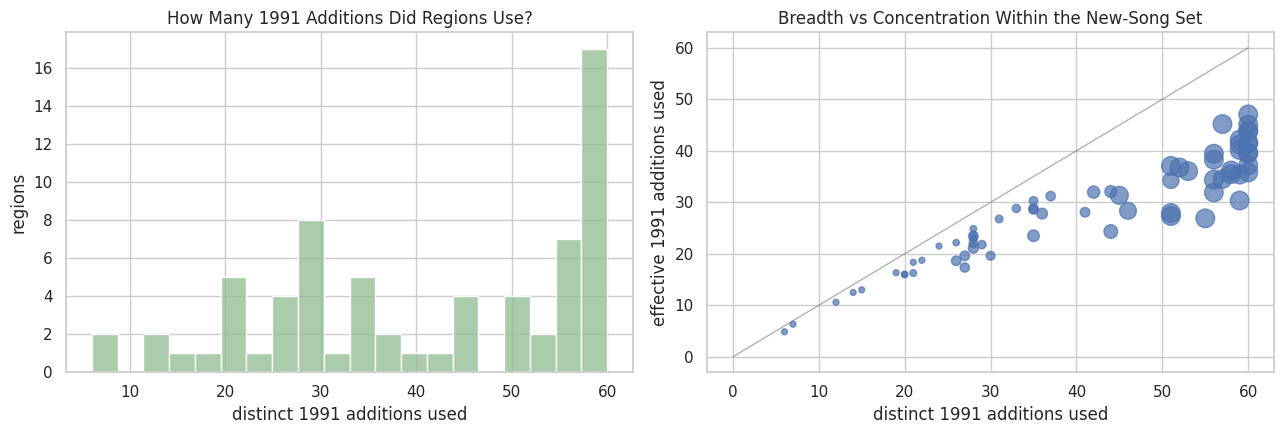

,region_label,new_song_lessons,new_songs_used,new_songs_used_pct,effective_new_song_count,effective_new_song_pct,new_song_lesson_share
region_id,,,,,,,
S001,West Georgia,5547,60,100.0%,47.1,78.4%,13.23%
S004,Northeast Alabama,5597,60,100.0%,45.1,75.1%,9.47%
S010,Pacific Northwest,2091,60,100.0%,43.9,73.1%,15.04%
S003,British Isles and Europe,3322,60,100.0%,43.8,73.1%,16.10%
S008,New England and Eastern Canada,3553,60,100.0%,41.6,69.4%,13.74%
S009,Mid-Atlantic,3982,60,100.0%,41.4,69.0%,17.03%
S020,Cleburne and Calhoun Counties,1408,60,100.0%,39.6,66.0%,10.30%
S007,Upper Midwest,5097,60,100.0%,39.5,65.8%,17.06%
S014,Ohio Valley,2585,60,100.0%,37.2,62.0%,16.89%


In [95]:
# @title
def effective_count(counts: pd.Series) -> float:
    counts = counts[counts > 0].astype(float)
    if counts.empty:
        return 0.0
    probs = counts / counts.sum()
    return float(np.exp(-(probs * np.log(probs)).sum()))


if REGIONS_PATH.exists() and SINGINGS_MAP_PATH.exists():
    region_song_set_counts = (
        regional_acceptance_facts[regional_acceptance_facts.is_1991_new]
        .groupby(["region_id", "song_id"])
        .size()
        .rename("new_song_lessons")
        .reset_index()
    )
    effective_new_song_counts = region_song_set_counts.groupby("region_id").new_song_lessons.apply(effective_count)

    region_new_song_coverage = region_acceptance_summary.copy()
    region_new_song_coverage["effective_new_song_count"] = effective_new_song_counts
    region_new_song_coverage["effective_new_song_count"] = region_new_song_coverage.effective_new_song_count.fillna(0)
    region_new_song_coverage["effective_new_song_pct"] = region_new_song_coverage.effective_new_song_count / len(new_song_ids)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    sns.histplot(region_new_song_coverage.new_songs_used, bins=20, ax=axes[0], color="darkseagreen")
    axes[0].set_title("How Many 1991 Additions Did Regions Use?")
    axes[0].set_xlabel("distinct 1991 additions used")
    axes[0].set_ylabel("regions")

    axes[1].scatter(
        region_new_song_coverage.new_songs_used,
        region_new_song_coverage.effective_new_song_count,
        s=np.clip(region_new_song_coverage.new_song_lessons / 2, 18, 180),
        alpha=0.7,
    )
    axes[1].plot([0, len(new_song_ids)], [0, len(new_song_ids)], color="0.4", lw=1, alpha=0.5)
    axes[1].set_title("Breadth vs Concentration Within the New-Song Set")
    axes[1].set_xlabel("distinct 1991 additions used")
    axes[1].set_ylabel("effective 1991 additions used")

    plt.tight_layout()
    plt.show()

    display(region_new_song_coverage.sort_values(
        ["new_songs_used", "effective_new_song_count", "new_song_lessons"],
        ascending=False,
    )[
        [
            "region_label", "new_song_lessons", "new_songs_used", "new_songs_used_pct",
            "effective_new_song_count", "effective_new_song_pct", "new_song_lesson_share",
        ]
    ].head(15).style.format({
        "new_songs_used_pct": "{:.1%}",
        "effective_new_song_count": "{:.1f}",
        "effective_new_song_pct": "{:.1%}",
        "new_song_lesson_share": "{:.2%}",
    }))


### Broadly Balanced vs Regionally Concentrated Songs

These tables use only songs with at least `MIN_REGION_SONG_LESSONS` mapped regional lessons. The first table surfaces songs whose use most closely tracks overall regional opportunity; the second surfaces songs with the most concentrated regional profiles.

In [96]:
# @title
if REGIONS_PATH.exists() and SINGINGS_MAP_PATH.exists():
    balanced_display = song_region_balance.sort_values(
        ["regional_balance_score", "mapped_regional_lessons"],
        ascending=[False, False],
    )[display_cols]
    display(balanced_display.head(12))


,page_num,title,mapped_regional_lessons,regions_with_lessons,effective_regions,regional_balance_score,top_region_id,top_region_label,top_region_lesson_share,associated_region_count,associated_regions,max_lift
40,475,A Thankful Heart,3525,62,26.161832,0.872524,S004,Northeast Alabama,0.122837,2,"S071 (2.6x, n=4); S108 (2.3x, n=7)",2.645694
48,503,Lloyd,3099,64,29.570159,0.861033,S001,West Georgia,0.099064,9,"S071 (3.0x, n=4); S078 (2.5x, n=8); S073 (2.5x...",3.009381
0,34b,St. Thomas,2802,61,30.832608,0.849741,S007,Upper Midwest,0.075660,7,"S108 (6.7x, n=16); S107 (3.2x, n=3); S092 (3.0...",6.748754
38,472,Akin,2010,59,27.921705,0.814756,S004,Northeast Alabama,0.114925,8,"S067 (4.4x, n=14); S052 (3.5x, n=24); S115 (3....",4.443625
3,66,Jordan,1941,59,28.077890,0.808336,S007,Upper Midwest,0.091705,6,"S093 (3.5x, n=9); S033 (3.1x, n=11); S078 (3.0...",3.533974
18,284,Garden Hymn,1091,48,25.314675,0.799872,S001,West Georgia,0.126489,4,"S068 (7.3x, n=4); S030 (3.5x, n=14); S033 (2.5...",7.346099
17,278t,Love Shall Never Die,985,53,27.635465,0.797984,S004,Northeast Alabama,0.111675,8,"S119 (5.3x, n=5); S089 (4.3x, n=3); S104 (3.4x...",5.324593
53,540,Nidrah,836,46,24.982165,0.796334,S004,Northeast Alabama,0.154306,7,"S096 (4.1x, n=4); S114 (4.0x, n=3); S030 (3.9x...",5.091763
29,354t,Lebanon,1127,53,28.672380,0.790613,S001,West Georgia,0.126886,5,"S104 (5.3x, n=7); S025 (3.6x, n=46); S096 (3.1...",5.274711
12,229,Irwinton,1136,52,26.801133,0.788406,S001,West Georgia,0.117958,4,"S038 (3.4x, n=14); S025 (3.1x, n=40); S006 (2....",3.569379


In [97]:
# @title
if REGIONS_PATH.exists() and SINGINGS_MAP_PATH.exists():
    concentrated_display = song_region_balance.sort_values(
        # ["regions_with_lessons", "top_region_lesson_share", "max_lift", "mapped_regional_lessons"],
        # ascending=[True, False, False, False],
        ["regional_balance_score", "mapped_regional_lessons"],
        ascending=[True, False],
    )[display_cols + ["top_region_label"]]
    display(concentrated_display.head(15))


,page_num,title,mapped_regional_lessons,regions_with_lessons,effective_regions,regional_balance_score,top_region_id,top_region_label,top_region_lesson_share,associated_region_count,associated_regions,max_lift,top_region_label
21,315,Immensity,533,39,17.788227,0.534553,S009,Mid-Atlantic,0.168856,9,"S106 (8.5x, n=4); S108 (6.7x, n=3); S116 (6.6x...",8.497596,Mid-Atlantic
51,516,DeLong,214,28,12.371238,0.543159,S001,West Georgia,0.285047,4,"S001 (3.5x, n=61); S006 (3.4x, n=32); S015 (3....",3.486091,West Georgia
42,484,Heavenly Union,152,27,16.701010,0.548565,S009,Mid-Atlantic,0.171053,6,"S104 (16.8x, n=3); S038 (5.5x, n=3); S023 (4.4...",16.761088,Mid-Atlantic
19,303,Heavenly Land,878,40,15.344717,0.581793,S006,East Alabama and West Georgia,0.205011,8,"S097 (7.8x, n=3); S088 (4.9x, n=12); S006 (4.6...",7.754964,East Alabama and West Georgia
28,353,McGraw,315,35,17.910938,0.587302,S004,Northeast Alabama,0.133333,3,"S052 (8.3x, n=9); S003 (2.9x, n=37); S021 (2.0...",8.279806,Northeast Alabama
50,510,Corley,429,40,17.664246,0.587653,S001,West Georgia,0.221445,7,"S114 (7.8x, n=3); S096 (6.0x, n=3); S105 (3.7x...",7.814708,West Georgia
36,466,Haynes Creek,352,35,20.182067,0.593040,S003,British Isles and Europe,0.122159,8,"S096 (12.3x, n=5); S025 (3.8x, n=15); S005 (3....",12.286668,British Isles and Europe
35,464,Sheppard,421,40,16.701014,0.598086,S007,Upper Midwest,0.192399,3,"S007 (3.3x, n=81); S105 (2.4x, n=5); S053 (2.0...",5.787984,Upper Midwest
32,393,Alexander,217,32,18.859239,0.600980,S001,West Georgia,0.161290,6,"S040 (16.2x, n=4); S038 (3.8x, n=3); S023 (3.1...",16.190076,West Georgia
59,570,Farewell to All,141,28,14.300527,0.601406,S001,West Georgia,0.212766,2,"S020 (3.7x, n=14); S001 (2.6x, n=30)",9.912343,West Georgia


### Top-Region Share

This table asks a simpler question: for each song, what share of its mapped regional lessons are in its single strongest region? It is a useful companion to the balance score because it gives an intuitive concentration measure: even the most regionally concentrated 1991 additions still appear across many co-attendance regions.

In [98]:
# @title
if REGIONS_PATH.exists() and SINGINGS_MAP_PATH.exists():
    top_region_share_display = (
        song_region_balance.sort_values(
            ["top_region_lesson_share", "mapped_regional_lessons"],
            ascending=[False, False],
        )
        .assign(
            top_region_lesson_pct=lambda df: (df.top_region_lesson_share * 100).round(1),
            regional_balance_score=lambda df: df.regional_balance_score.round(3),
            max_lift=lambda df: df.max_lift.round(2),
        )
    )

    display(top_region_share_display[
        [
            "page_num", "title",
            "top_region_id", "top_region_label", "top_region_lessons", "top_region_lesson_pct",
            "regional_balance_score", "max_lift",
            "mapped_regional_lessons", "regions_with_lessons",
        ]
    ].head(20))


,page_num,title,top_region_id,top_region_label,top_region_lessons,top_region_lesson_pct,regional_balance_score,max_lift,mapped_regional_lessons,regions_with_lessons
51,516,DeLong,S001,West Georgia,61,28.5,0.543,3.49,214,28
45,494,Big Creek,S001,West Georgia,92,25.6,0.617,5.83,360,38
30,368,Stony Point,S007,Upper Midwest,128,24.6,0.633,8.15,520,40
50,510,Corley,S001,West Georgia,95,22.1,0.588,7.81,429,40
59,570,Farewell to All,S001,West Georgia,30,21.3,0.601,9.91,141,28
19,303,Heavenly Land,S006,East Alabama and West Georgia,180,20.5,0.582,7.75,878,40
2,50b,Humility,S001,West Georgia,76,20.5,0.637,8.27,371,33
35,464,Sheppard,S007,Upper Midwest,81,19.2,0.598,5.79,421,40
27,352,Swanton,S007,Upper Midwest,118,19.2,0.648,11.09,614,46
43,485,New Agatite,S007,Upper Midwest,129,17.8,0.696,5.57,724,50


### Songs Unique To One Region

This is intentionally stricter than “appears once somewhere”: a song must have all mapped regional lessons in one region and at least `MIN_REGION_SONG_LESSONS` mapped regional lessons overall.

In [99]:
# @title
if REGIONS_PATH.exists() and SINGINGS_MAP_PATH.exists():
    unique_to_one_region = song_region_balance[
        song_region_balance.regions_with_lessons.eq(1)
    ].sort_values(["mapped_regional_lessons", "max_lift"], ascending=False)

    unique_display_cols = ["page_num", "title", "mapped_regional_lessons", "top_region_id", "top_region_label", "max_lift"]
    if unique_to_one_region.empty:
        print(
            "No 1991 additions are unique to a single mapped co-attendance region "
            f"at the current cutoff of {MIN_REGION_SONG_LESSONS} mapped regional lessons."
        )
        print("Showing the most regionally concentrated songs instead.")
        display(concentrated_display.head(15))
    else:
        display(unique_to_one_region[unique_display_cols].head(20))


No 1991 additions are unique to a single mapped co-attendance region at the current cutoff of 8 mapped regional lessons.
Showing the most regionally concentrated songs instead.


,page_num,title,mapped_regional_lessons,regions_with_lessons,effective_regions,regional_balance_score,top_region_id,top_region_label,top_region_lesson_share,associated_region_count,associated_regions,max_lift,top_region_label
21,315,Immensity,533,39,17.788227,0.534553,S009,Mid-Atlantic,0.168856,9,"S106 (8.5x, n=4); S108 (6.7x, n=3); S116 (6.6x...",8.497596,Mid-Atlantic
51,516,DeLong,214,28,12.371238,0.543159,S001,West Georgia,0.285047,4,"S001 (3.5x, n=61); S006 (3.4x, n=32); S015 (3....",3.486091,West Georgia
42,484,Heavenly Union,152,27,16.701010,0.548565,S009,Mid-Atlantic,0.171053,6,"S104 (16.8x, n=3); S038 (5.5x, n=3); S023 (4.4...",16.761088,Mid-Atlantic
19,303,Heavenly Land,878,40,15.344717,0.581793,S006,East Alabama and West Georgia,0.205011,8,"S097 (7.8x, n=3); S088 (4.9x, n=12); S006 (4.6...",7.754964,East Alabama and West Georgia
28,353,McGraw,315,35,17.910938,0.587302,S004,Northeast Alabama,0.133333,3,"S052 (8.3x, n=9); S003 (2.9x, n=37); S021 (2.0...",8.279806,Northeast Alabama
50,510,Corley,429,40,17.664246,0.587653,S001,West Georgia,0.221445,7,"S114 (7.8x, n=3); S096 (6.0x, n=3); S105 (3.7x...",7.814708,West Georgia
36,466,Haynes Creek,352,35,20.182067,0.593040,S003,British Isles and Europe,0.122159,8,"S096 (12.3x, n=5); S025 (3.8x, n=15); S005 (3....",12.286668,British Isles and Europe
35,464,Sheppard,421,40,16.701014,0.598086,S007,Upper Midwest,0.192399,3,"S007 (3.3x, n=81); S105 (2.4x, n=5); S053 (2.0...",5.787984,Upper Midwest
32,393,Alexander,217,32,18.859239,0.600980,S001,West Georgia,0.161290,6,"S040 (16.2x, n=4); S038 (3.8x, n=3); S023 (3.1...",16.190076,West Georgia
59,570,Farewell to All,141,28,14.300527,0.601406,S001,West Georgia,0.212766,2,"S020 (3.7x, n=14); S001 (2.6x, n=30)",9.912343,West Georgia


### Songs Strongly Associated With Several Regions

A region counts as an association when the song has at least `MIN_ASSOCIATION_LESSONS_IN_REGION` lessons there and at least `MIN_ASSOCIATION_LIFT` times the background expectation. These are candidates for songs that are not exactly global, but also not confined to a single neighborhood.

In [100]:
# @title
if REGIONS_PATH.exists() and SINGINGS_MAP_PATH.exists():
    multi_region_associations = song_region_balance[
        song_region_balance.associated_region_count.ge(2)
    ].sort_values(
        ["associated_region_count", "max_lift", "mapped_regional_lessons"],
        ascending=False,
    )

    display(multi_region_associations[display_cols].head(20))


,page_num,title,mapped_regional_lessons,regions_with_lessons,effective_regions,regional_balance_score,top_region_id,top_region_label,top_region_lesson_share,associated_region_count,associated_regions,max_lift
8,163b,China,2081,61,29.214747,0.780205,S007,Upper Midwest,0.087458,17,"S093 (3.3x, n=9); S114 (3.2x, n=6); S092 (3.1x...",3.296225
49,504,Wood Street,1750,56,23.092728,0.660533,S007,Upper Midwest,0.101714,16,"S066 (4.6x, n=5); S081 (4.0x, n=8); S093 (3.9x...",4.551322
54,547,Granville,1662,54,23.462212,0.674722,S007,Upper Midwest,0.131167,13,"S108 (5.0x, n=7); S124 (4.5x, n=3); S053 (3.1x...",4.977815
9,178,Africa,3199,66,29.161832,0.769353,S007,Upper Midwest,0.093467,13,"S040 (3.6x, n=13); S108 (3.3x, n=9); S081 (3.3...",3.569256
23,347,Christian’s Farewell,1729,56,26.924938,0.716935,S007,Upper Midwest,0.109890,12,"S092 (6.2x, n=5); S096 (6.0x, n=12); S025 (3.8...",6.154878
22,344,Rainbow,2061,59,25.456017,0.724578,S007,Upper Midwest,0.111596,12,"S081 (4.3x, n=10); S068 (3.9x, n=4); S108 (2.9...",4.283585
6,117,Babylon Is Fallen,1646,62,28.345610,0.766093,S001,West Georgia,0.097205,12,"S114 (4.1x, n=6); S094 (3.7x, n=3); S068 (3.7x...",4.073523
39,474,Mount Desert,1498,51,20.776126,0.652263,S007,Upper Midwest,0.124833,11,"S107 (6.1x, n=3); S106 (5.3x, n=7); S108 (4.7x...",6.078329
5,86,Poland,1770,61,26.543626,0.715294,S007,Upper Midwest,0.112994,11,"S103 (3.6x, n=3); S081 (3.5x, n=7); S106 (3.2x...",3.592478
4,77b,Holcombe,814,49,23.085519,0.692866,S001,West Georgia,0.165848,10,"S104 (8.3x, n=8); S074 (5.0x, n=4); S069 (4.5x...",8.346226


In [102]:
# @title
if REGIONS_PATH.exists() and SINGINGS_MAP_PATH.exists():
    interesting_song_ids = pd.concat([
        unique_to_one_region.head(5)[["song_id"]],
        multi_region_associations.head(5)[["song_id"]],
        song_region_balance.sort_values("regional_balance_score", ascending=False).head(5)[["song_id"]],
        song_region_balance.sort_values("regional_balance_score", ascending=True).head(5)[["song_id"]],
    ]).drop_duplicates().song_id.tolist()

    interesting_region_profiles = new_song_region_counts[
        new_song_region_counts.song_id.isin(interesting_song_ids)
    ].merge(
        new_songs[["song_id", "page_num", "title"]],
        on="song_id",
        how="left",
    ).sort_values(
        ["song_id", "song_region_lessons"],
        ascending=[True, False],
    )

    display(interesting_region_profiles[
        [
            "page_num", "title", "region_id", "region_label", "song_region_lessons",
            "regional_share_of_lessons", "lift_vs_regional_background", "song_region_records",
            "song_region_singings",
        ]
    ].head(80))


,page_num,title,region_id,region_label,song_region_lessons,regional_share_of_lessons,lift_vs_regional_background,song_region_records,song_region_singings
6,34b,St. Thomas,S007,Upper Midwest,212,0.007096,1.298949,196,14
3,34b,St. Thomas,S004,Northeast Alabama,194,0.003283,0.601030,170,17
0,34b,St. Thomas,S001,West Georgia,193,0.004602,0.842387,179,16
8,34b,St. Thomas,S009,Mid-Atlantic,174,0.007443,1.362496,150,9
10,34b,St. Thomas,S011,California and Mountain West,126,0.006514,1.192388,109,11
...,...,...,...,...,...,...,...,...,...
79,66,Jordan,S019,Indiana and Illinois,46,0.006482,1.712849,44,5
62,66,Jordan,S002,Northwest Alabama,42,0.002013,0.531971,41,10
81,66,Jordan,S021,Pennsylvania,39,0.003739,0.988135,38,5
65,66,Jordan,S005,Northern England,37,0.003361,0.888076,37,11
